<a href="https://colab.research.google.com/github/ananyatolanur/Vtu-internship-projects/blob/main/ANANYA_TOLANUR_ASSINGMENT1_MLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Multiple Linear Regression on CF Housing Price Dataset

## About Dataset
The CF Housing Price dataset contains information related to house properties and amenities.
The objective is to predict **house price** using **Multiple Linear Regression** based on multiple independent variables.



## Key Column Description
- **price**: House price (Target variable)
- **area**: Area of the house
- **bedrooms**: Number of bedrooms
- **bathrooms**: Number of bathrooms
- **stories**: Number of floors
- **mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea**: Yes/No features
- **furnishingstatus**: Furnishing condition


## Importing Necessary Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


## Loading and Reading Data

In [ ]:

df = pd.read_csv("Assignment_1_MLR_CF_Housing_Price.csv")
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
#To know the number of rows and coloumns of the dataset
df.shape

(545, 13)

## Descriptive Statistics (Univariate Analysis)

In [ ]:
#df.describe() is used to generate summary statistics (mean, standard deviation, min, max, quartiles, etc.) for numerical columns in the dataset.
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Removing Duplicate Rows

In [ ]:
df = df.drop_duplicates()

## Checking Null Values

In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


## Exploratory Data Analysis (EDA)

## Univariate Analysis

Univariate analysis studies one variable independently to understand its distribution and summary statistics.

### Distribution of House Prices

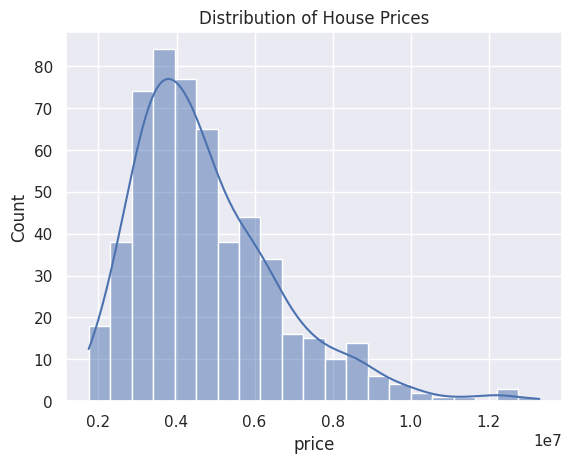

In [ ]:

plt.figure()
sns.histplot(df['price'], kde=True)
plt.title("Distribution of House Prices")
plt.show()


### Area Distribution

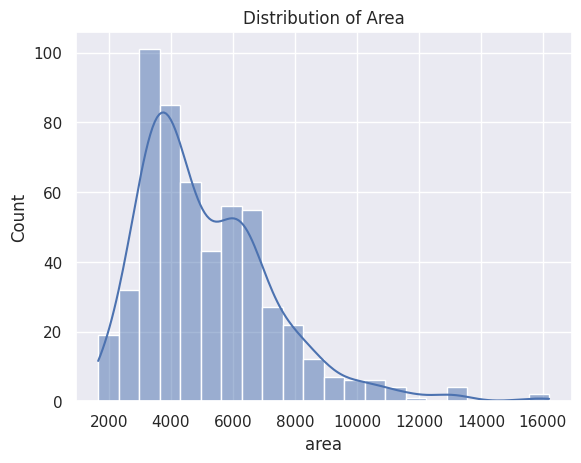

In [ ]:

plt.figure()
sns.histplot(df['area'], kde=True)
plt.title("Distribution of Area")
plt.show()


### Bedrooms Count

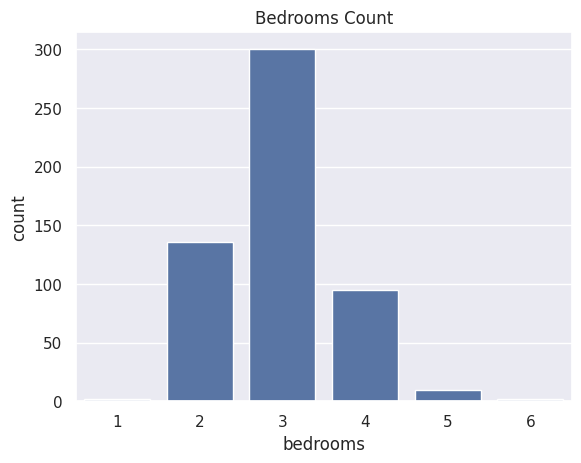

In [ ]:

plt.figure()
sns.countplot(x=df['bedrooms'])
plt.title("Bedrooms Count")
plt.show()


## Bivariate Analysis

### Area vs Price

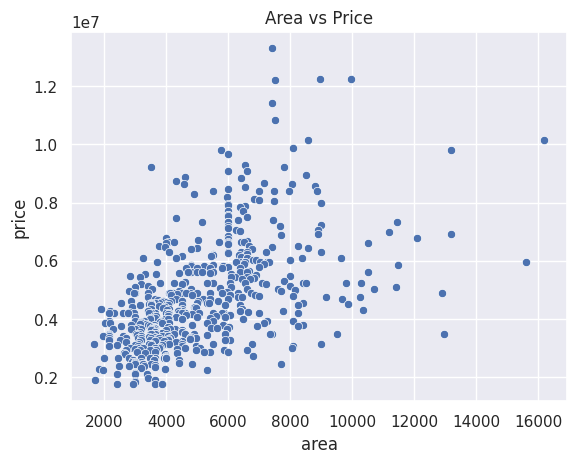

In [ ]:

plt.figure()
sns.scatterplot(x=df['area'], y=df['price'])
plt.title("Area vs Price")
plt.show()


### Bedrooms vs Price

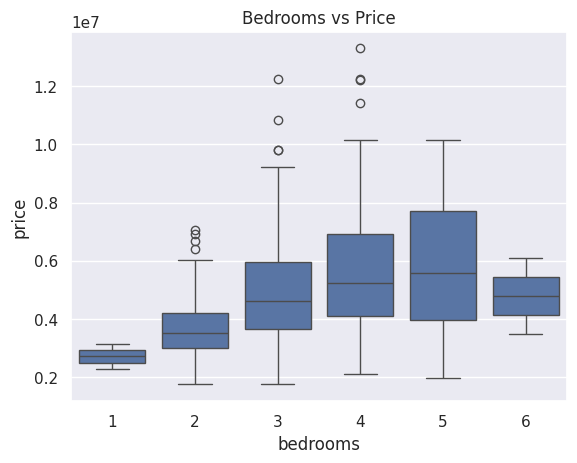

In [ ]:

plt.figure()
sns.boxplot(x=df['bedrooms'], y=df['price'])
plt.title("Bedrooms vs Price")
plt.show()


### Furnishing Status vs Price

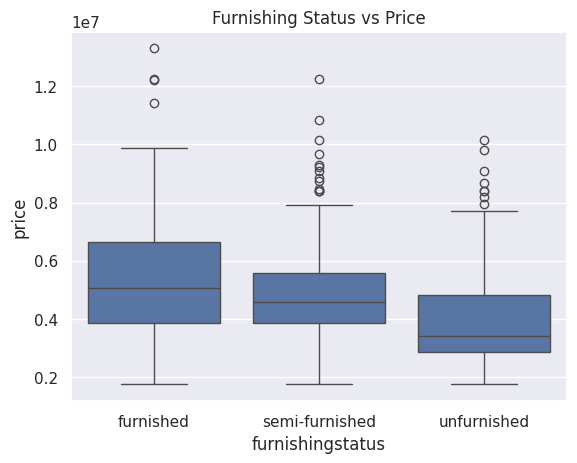

In [ ]:

plt.figure()
sns.boxplot(x=df['furnishingstatus'], y=df['price'])
plt.title("Furnishing Status vs Price")
plt.show()


## Outlier Check

### Price Outliers

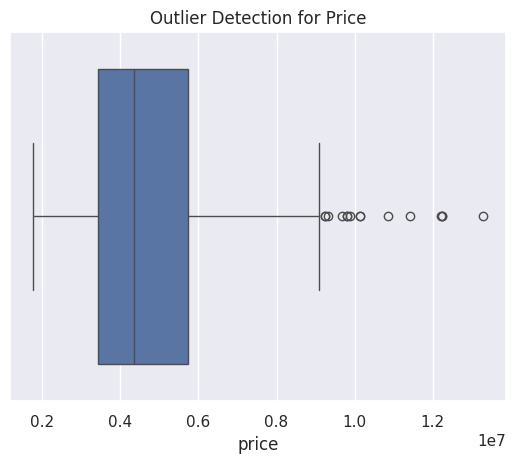

In [ ]:

plt.figure()
sns.boxplot(x=df['price'])
plt.title("Outlier Detection for Price")
plt.show()


### Area Outliers

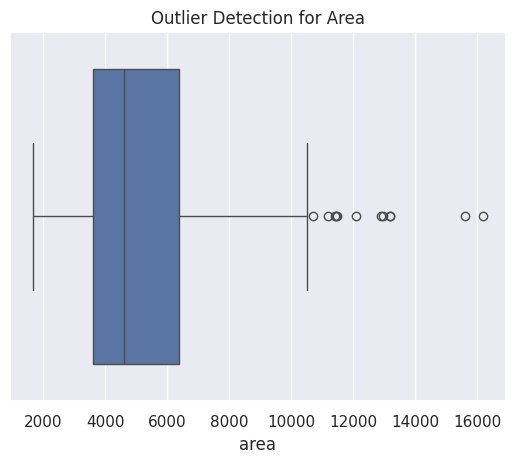

In [ ]:

plt.figure()
sns.boxplot(x=df['area'])
plt.title("Outlier Detection for Area")
plt.show()



## Preparation of Data Before Training
Steps involved:
1. Encoding categorical variables  
2. Feature selection  
3. Separating X and y  
4. Train-test split  
5. Model training  


In [ ]:

# Encoding categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Feature and target split
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]


In [ ]:
X = X.astype(float)

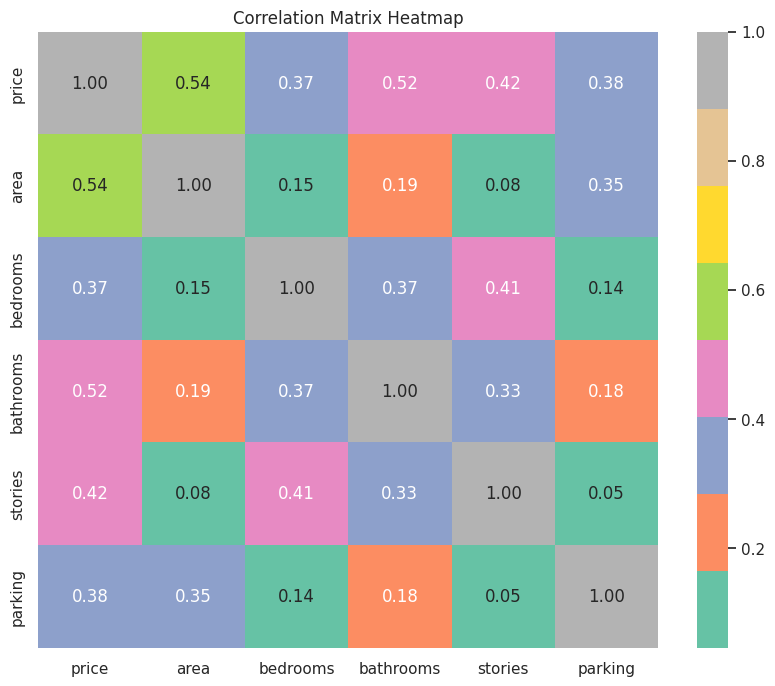

In [ ]:
# Finding correlation between numerical variables
plt.figure(figsize=(10, 8))

# Select only numerical columns
df_num = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = df_num.corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='Set2', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

Variance Inflation Factor (VIF) is used to measure multicollinearity among independent variables, and features with high VIF values indicate strong correlation with other predictors.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Feature,VIF
0,area,8.276447
1,bedrooms,16.652387
2,bathrooms,9.417643
3,stories,7.880730
4,parking,1.986400
5,mainroad_yes,6.884806
6,guestroom_yes,1.473234
7,basement_yes,2.019858
8,hotwaterheating_yes,1.091568
9,airconditioning_yes,1.767753


This line removes the feature ‘bedrooms’ from the independent variables to reduce multicollinearity before training the regression model as vif > 5

In [ ]:
X = X.drop(['bedrooms'], axis=1)

1. Variance Inflation Factor (VIF) is calculated to detect multicollinearity among independent variables.
2. Features with high VIF values indicate strong correlation with other predictors.
3. The feature with the highest VIF is removed first to reduce multicollinearity.
4. After removing one feature, VIF is recalculated to check the effect on remaining variables.
5. This process is repeated until all features have acceptable VIF values.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Feature,VIF
0,area,7.721882
1,bathrooms,8.010130
2,stories,6.336739
3,parking,1.984635
4,mainroad_yes,6.766129
5,guestroom_yes,1.469309
6,basement_yes,1.919643
7,hotwaterheating_yes,1.090974
8,airconditioning_yes,1.765240
9,prefarea_yes,1.493542


In [ ]:
X = X.drop(['bathrooms'], axis=1)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Feature,VIF
0,area,7.116608
1,stories,4.942363
2,parking,1.967207
3,mainroad_yes,6.709752
4,guestroom_yes,1.468723
5,basement_yes,1.829024
6,hotwaterheating_yes,1.085384
7,airconditioning_yes,1.763784
8,prefarea_yes,1.489922
9,furnishingstatus_semi-furnished,2.182030


Although the VIF value of 'area' is above the threshold (VIF > 5),
it was retained in the final model because it is a highly influential feature
in predicting house price. Removing 'area' resulted in a noticeable drop
in model performance (lower accuracy and R² score).
Therefore, 'area' was kept to maintain predictive strength while accepting
moderate multicollinearity.

In [ ]:
#X = X.drop(['area'], axis=1)

In [ ]:
# Recreate X with all selected features (including area)
#X = df_encoded.drop("price", axis=1)

## Split the Data (70% Train and 30% Test)

The dataset was divided into 70% training and 30% testing data to evaluate the model’s performance on unseen data.

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


 Model is trained using standardized features to ensure uniform scaling
 and improved numerical stability.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

## Model Training – Multiple Linear Regression

In [ ]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

## Model Coefficients

In [ ]:

pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})


,Feature,Coefficient
0,area,643879.242683
1,stories,566354.095499
2,parking,298524.807442
3,mainroad_yes,89059.868710
4,guestroom_yes,89669.393999
5,basement_yes,327961.697478
6,hotwaterheating_yes,153345.050561
7,airconditioning_yes,345611.485682
8,prefarea_yes,187944.004955
9,furnishingstatus_semi-furnished,-49105.632479


Final Multiple Linear Regression Equation:

In [ ]:
intercept = model.intercept_
coefficients = model.coef_

print("Final Multiple Linear Regression Equation:\n")
print(f"Price = {intercept:.2f}", end=" ")

for feature, coef in zip(X.columns, coefficients):
    sign = "+" if coef >= 0 else "-"
    print(f"{sign} {abs(coef):.2f}*{feature}", end=" ")

print()

Final Multiple Linear Regression Equation:

Price = 4762406.27 + 643879.24*area + 566354.10*stories + 298524.81*parking + 89059.87*mainroad_yes + 89669.39*guestroom_yes + 327961.70*basement_yes + 153345.05*hotwaterheating_yes + 345611.49*airconditioning_yes + 187944.00*prefarea_yes - 49105.63*furnishingstatus_semi-furnished - 199977.34*furnishingstatus_unfurnished 


## Predictions on the Test Set

In [ ]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Mean Absolute Error
MAE = mean_absolute_error(y_test, y_pred)
print(f'1. Mean Absolute Error (MAE) = {MAE}')

# Mean Squared Error
MSE = mean_squared_error(y_test, y_pred)
print(f'2. Mean Squared Error (MSE) = {MSE}')

# Root Mean Squared Error
RMSE = np.sqrt(MSE)
print(f'3. Root Mean Squared Error (RMSE) = {RMSE}')

# Mean Absolute Percentage Error
MAPE = mean_absolute_percentage_error(y_test, y_pred)
print(f'4. Mean Absolute Percentage Error (MAPE) = {MAPE}')

# Accuracy Calculation
ACC = 100 - (MAPE * 100)
print(f'5. Accuracy of the Model = {ACC}%')

# R2 Score
R2 = r2_score(y_test, y_pred)
print(f'6. R2 Score = {R2}')

1. Mean Absolute Error (MAE) = 942814.8545820289
2. Mean Squared Error (MSE) = 1697164873813.1304
3. Root Mean Squared Error (RMSE) = 1302752.8061044929
4. Mean Absolute Percentage Error (MAPE) = 0.2159932882417903
5. Accuracy of the Model = 78.40067117582097%
6. R2 Score = 0.6058962620283884


It prints the constant term (β₀) in the regression equation.

In equation form:
𝑃𝑟𝑖𝑐𝑒 =𝛽0+𝛽1𝑋1+𝛽2𝑋2+...Price=β0+β1X1+β2X2+...
Here:
model.intercept_ = β₀

In [ ]:
print("Intercept:", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(f"{coef} * {feature}")

Intercept: 4762406.272965879
643879.2426828584 * area
566354.0954988027 * stories
298524.80744181445 * parking
89059.8687096024 * mainroad_yes
89669.39399869027 * guestroom_yes
327961.69747782423 * basement_yes
153345.05056078 * hotwaterheating_yes
345611.485682333 * airconditioning_yes
187944.00495527236 * prefarea_yes
-49105.63247907298 * furnishingstatus_semi-furnished
-199977.34448908965 * furnishingstatus_unfurnished


In [ ]:
model.intercept_
model.coef_

array([ 2.96110141e+02,  6.57233597e+05,  3.57052676e+05,  2.59422360e+05,
        2.30281574e+05,  6.83428215e+05,  6.87584598e+05,  7.42392855e+05,
        4.42471909e+05, -9.92508502e+04, -4.32500780e+05])

In [ ]:
# Training Prediction
y_pred_train = model.predict(X_train_scaled)
err_train = y_train - y_pred_train
Train_r2 = r2_score(y_train, y_pred_train)

# Test Prediction
y_pred_test = model.predict(X_test_scaled)
err_test = y_test - y_pred_test
Test_r2 = r2_score(y_test, y_pred_test)

print('Train R2 Score :', Train_r2)
print('Test R2 Score  :', Test_r2)

Train R2 Score : 0.6151196939485484
Test R2 Score  : 0.6058962620283884


# Train vs Test Predictions Graph

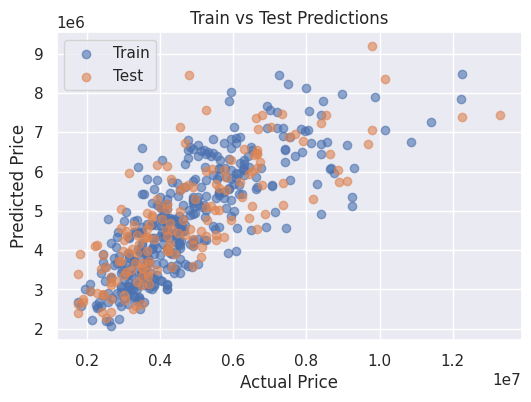

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_train, y_pred_train, label='Train', alpha=0.6)
plt.scatter(y_test, y_pred, label='Test', alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Train vs Test Predictions")
plt.legend()
plt.show()

# Residual Plot

The residual plot shows that errors are randomly distributed around zero with no clear pattern, indicating that the linear regression assumptions are reasonably satisfied.

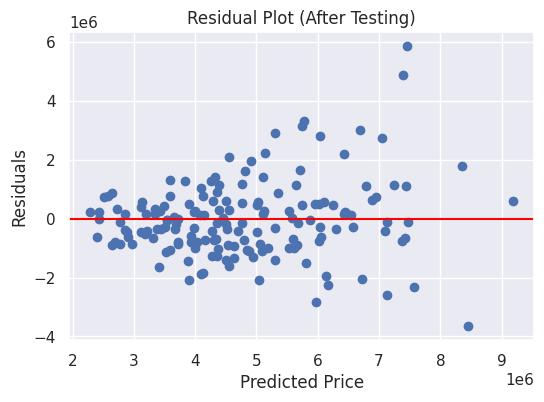

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot (After Testing)")
plt.show()

## Actual vs Predicted Prices

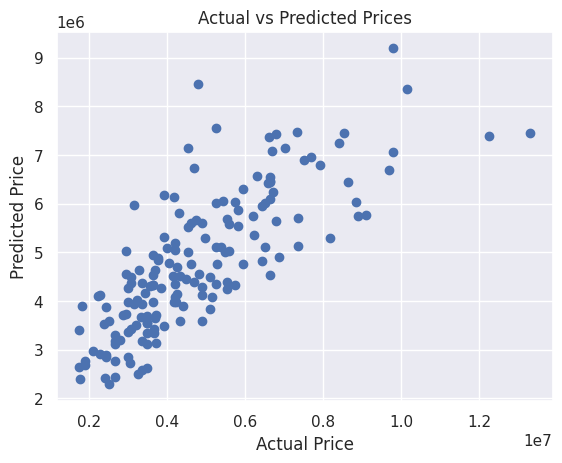

In [ ]:

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()



## Conclusion
Multiple Linear Regression was successfully applied on the CF Housing Price dataset. Exploratory Data Analysis (EDA) helped in understanding feature relationships and identifying outliers. The trained model was evaluated using standard regression metrics. The Train R² score (0.615) and Test R² score (0.606) are very close to each other, indicating that the model generalizes well on unseen data and does not suffer from overfitting. Hence, the developed regression model can be considered a good and stable predictive model for house price estimation.
